In [2]:
# Imports
from pathlib import Path
from experiment.utils import TrainedModel, TrainedModelID, get_losses

import pandas as pd
import torch
from neuralhydrology.nh_run import start_run, eval_run, finetune
from experiment.eval import evaluate_models
import os
import yaml
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
model = TrainedModel(TrainedModelID.SOTA_20)

df = pd.read_csv(model.metrics_file, dtype={'basin':str})
cutoff = 0.0
time = int(datetime.now().timestamp())
basin_data = df.loc[df['NSE'] > cutoff].sample(n=1, random_state=time)
basin = basin_data.basin.iloc[0]
nse = basin_data.NSE.iloc[0]
print(basin)
print(nse)

04213000
0.7419546544551849


In [8]:
# Add the path to the pre-trained model to the finetune config
file_path = "assets/finetune.yml"

with open(file_path, "a") as fp:
    fp.write(f"\nbase_run_dir: {model.run_dir.absolute()}")

# Load the existing YAML data
with open(file_path, 'r') as f:
    data = yaml.safe_load(f)

data['experiment_name'] = f'basin_{basin}'  # Example modification

# Write back to the YAML file
with open(file_path, 'w') as f:
    yaml.dump(data, f)   

# Create a basin file with the basin we selected above
with open("assets/finetune_basin.txt", "w") as fp:
    fp.write(basin)


In [9]:
finetuned_model = finetune(Path('assets/finetune.yml'))

2024-09-30 13:19:11,996: Logging to /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/output.log initialized.
2024-09-30 13:19:11,997: ### Folder structure created at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000
2024-09-30 13:19:11,998: ### Start finetuning with pretrained model stored in /home/admin/Fine-Flood-Forecasts/experiment/models/runs/sota_20
2024-09-30 13:19:11,998: ### Run configurations for basin_04213000
2024-09-30 13:19:11,998: additional_feature_files: None
2024-09-30 13:19:11,999: batch_size: 256
2024-09-30 13:19:11,999: checkpoint_path: None
2024-09-30 13:19:11,999: clip_gradient_norm: 1
2024-09-30 13:19:12,000: clip_targets_to_zero: ['QObs(mm/d)']
2024-09-30 13:19:12,001: commit_hash: 6dde7b4
2024-09-30 13:19:12,001: data_dir: /home/admin/Fine-Flood-Forecasts/data/CAMELS_US
2024-09-30 13:19:12,001: dataset: camels_us
2024-09-30 13:19:12,002: device: cuda:0
2024-09-30 13:19:12,002: dynamic_inputs: ['PRCP(mm/day)_nl

2024-09-30 13:19:12,008: loss: NSE
2024-09-30 13:19:12,012: metrics: ['NSE', 'KGE', 'MSE']
2024-09-30 13:19:12,012: model: cudalstm
2024-09-30 13:19:12,013: num_workers: 16
2024-09-30 13:19:12,014: number_of_basins: 1
2024-09-30 13:19:12,014: optimizer: Adam
2024-09-30 13:19:12,014: output_activation: linear
2024-09-30 13:19:12,015: output_dropout: 0.4
2024-09-30 13:19:12,015: package_version: 1.11.0
2024-09-30 13:19:12,016: predict_last_n: 1
2024-09-30 13:19:12,016: regularization: None
2024-09-30 13:19:12,017: run_dir: /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000
2024-09-30 13:19:12,018: save_weights_every: 1
2024-09-30 13:19:12,019: seed: 721924
2024-09-30 13:19:12,019: seq_length: 365
2024-09-30 13:19:12,020: static_attributes: ['elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_

2024-09-30 13:20:08,893: No path found after /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/events.out.tfevents.1727695152.moise-zencha.2423656.1


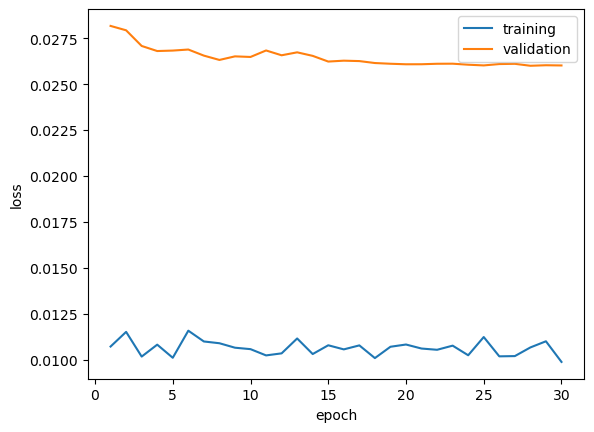

In [10]:
from experiment.finetuning.utils import get_training_losses
run_dir = Path(os.path.abspath('')) / 'runs' / f'basin_{basin}'
config_file_path = run_dir / 'config.yml'
fine_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
training_losses, validation_losses = get_training_losses(fine_model)
plt.plot(training_losses.step, training_losses.value, label='training')
plt.plot(validation_losses.step, validation_losses.value, label='validation')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()


In [11]:
from IPython.core.display import display, HTML

finetuned_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
df_basin = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='train', bolden_values = True)
df_all = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='validation', bolden_values = True)
display(HTML(data=df_basin.to_html(escape=False)))
display(HTML(data=df_all.to_html(escape=False)))

2024-09-30 13:20:16,135: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/model_epoch030.pt


/tmp/ipykernel_2423656/3388005891.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  3.68it/s]
2024-09-30 13:20:16,412: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/train/model_epoch030/train_metrics.csv
2024-09-30 13:20:16,413: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/train/model_epoch030/train_results.p
2024-09-30 13:20:16,441: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/model_epoch030.pt
# Validation: 100%|██████████| 1/1 [00:00<00:00,  3.61it/s]
2024-09-30 13:20:16,723: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/validation/model_epoch030/validation_metrics.csv
2024-09-30 13:20:16,724: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_04213000/validation/model_epoch030/validation_results.p


,Metric,sota_20,basin_04213000
0,NSE (mean),0.867,0.876
1,KGE (mean),0.914,0.89
2,MSE (mean),1.273,1.192
3,NSE (median),0.867,0.876
4,KGE (median),0.914,0.89
5,MSE (median),1.273,1.192


,Metric,sota_20,basin_04213000
0,NSE (mean),0.603,0.644
1,KGE (mean),0.706,0.744
2,MSE (mean),3.932,3.526
3,NSE (median),0.603,0.644
4,KGE (median),0.706,0.744
5,MSE (median),3.932,3.526


In [92]:
df_test = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='test', bolden_values = True)
display(HTML(data=df_test.to_html(escape=False)))

,Metric,sota_20,basin_07180500
0,NSE (mean),0.719,0.713
1,KGE (mean),0.755,0.741
2,MSE (mean),1.908,1.949
3,NSE (median),0.719,0.713
4,KGE (median),0.755,0.741
5,MSE (median),1.908,1.949


In [21]:
import pandas as pd
model = TrainedModel(TrainedModelID.SOTA_20)
metric = 'NSE'
fine_m = pd.read_csv(os.path.join('assets', model.config_id, 'finetuned_metrics.csv'), index_col='Metric').transpose().reset_index(drop=False).rename(columns={'index': 'basin'})
sota_m = pd.read_csv('../models/runs/sota_20/test/model_epoch030/test_metrics.csv', dtype={'basin':str})


FileNotFoundError: [Errno 2] No such file or directory: 'assets/sota_20/finetuned_metrics.csv'

In [29]:
fine_m = fine_m.map(lambda x: x.replace('<b>', '').replace('</b>',''))


In [30]:
merged_df = pd.merge(left=sota_m[['basin', f'{metric}']], right=fine_m[['basin', f'{metric} (mean)']], on='basin')
merged_df[f'{metric} (mean)'] = merged_df[f'{metric} (mean)'].astype(float)

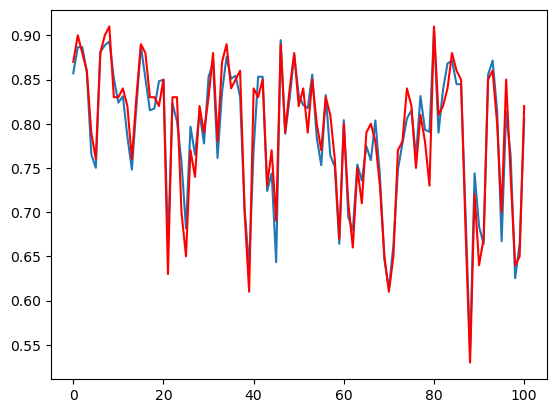

In [31]:
plt.plot(merged_df[f'{metric}'])
plt.plot(merged_df[f'{metric} (mean)'], 'r')


In [32]:
merged_df = merged_df.set_index('basin')

In [33]:
merged_df.mean(axis=0)

NSE           0.787824
NSE (mean)    0.789307
dtype: float64